# Visualization

- copy file using: `scp -r franklhtan@10.64.109.137:"/nfs/franklhtan/projects/LearnCsld2025/observe_outputs/0427_*" /mnt/data/Projects/LearnCsldLab/observations/`

In [8]:
# imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from itertools import product
import os
import warnings
warnings.filterwarnings("ignore")

In [9]:
def L1_condition_mapper(condition):
    if "_RCRC" in condition or "_RCCL" in condition:
        return "Recon"
    elif "_CLRC" in condition or "_CLCL" in condition:
        return "Class"

def L2_condition_mapper(condition):
    if "_RCRC" in condition or "_CLRC" in condition:
        return "Recon"
    elif "_RCCL" in condition or "_CLCL" in condition:
        return "Class"
    
def freezing_condition_mapper(condition):
    if "_FZ" in condition:
        return "Freeze"
    elif "_NFZ" in condition:
        return "NoFreeze"
    elif "_EWC" in condition:
        return "EWC"
    elif "_NPT" in condition:
        return "NoPreTrain"
    elif "_WEWC" in condition:
        return "WeakEWC"
    
def freezing_strength_mapper(condition):
    if "_EWC" in condition:
        # then get the number after EWC: p = +, n = -, number means power
        # e.g. p0 = 1e0, p3 = 1e3, n2 = 1e-2
        strength = condition.split("_EWC")[1].split("_")[0]
        if strength.startswith("p"):
            return "1e" + strength[1:]
        elif strength.startswith("n"):
            return "1e-" + strength[1:]
        else:
            return "1e" + strength
    else: 
        return "0"

def learning_rate_condition_mapper(condition):
    if "_1e5" in condition:
        return "slow"
    elif "_1e4" in condition:
        return "fast"
    elif "_1e3" in condition:
        return "superfast"
    
def L2_inventory_condition_mapper(condition):
    if "_PARA" in condition:
        return "Para"
    elif "_VERT" in condition:
        return "Vert"
    elif "_EQL" in condition:
        return "Equal"
    elif "_UQL" in condition:
        return "Unequal"
    elif "UAE" in condition:
        return "Unequal_as_Equal"
    
def model_hid_size_condition_mapper(condition):
    if "_HID" in condition:
        # then get the number after HID
        hid_size = condition.split("_HID")[1].split("_")[0]
        return hid_size
    else: 
        return "4"

In [10]:
TRAIN_MAP = {
    'e_e':'same', 'e_o':'back', 'e_i': 'height_L1', 
    'e_ih': 'hd_trained', 'e_iS': 'hd_untrained', 
    'e_ihL': 'height_L2', 'o_o': 'same', 'o_u': 'height_L1', 
    'o_uh': 'hd_trained', 'o_uS': 'hd_untrained', 'o_uhL': 'height_L2', 
    'i_i': 'same', 'i_u': 'back', 'i_ih': 'hd_trained', 'i_iS': 'duration',
    'i_ihL': 'height_L2', 'u_u': 'same', 'u_uh': 'hd_trained', 'u_uS': 'duration',
    'u_uhL': 'height_L2', 'ih_ih': 'same', 'ih_uh': 'back', 'ih_iS': 'height_L2', 'ih_ihL': 'duration',
    'uh_uh': 'same', 'uh_uS': 'height_L2', 'uh_uhL': 'duration', 'iS_iS': 'same',
    'iS_uS': 'back', 'iS_ihL': 'hd_untrained', 'uS_uS': 'same', 'uS_uhL': 'hd_untrained',
    'ihL_ihL': 'same', 'ihL_uhL': 'back', 'uhL_uhL': 'same'
}

In [22]:
BASE_PATH = "./observations/"

PREFIX = "0501"
# L1_CONDITIONS = ["RC"]
# L2_CONDITIONS = ["RC"]
L1_CONDITIONS = ["CL"]
L2_CONDITIONS = ["CL"]
FREEZING_CONDITIONS = ["EWC"]
# FREEZING_STRENGTHS = ["p3", "p6"]
FREEZING_STRENGTHS = ["p0", "n3"]
LEARNING_RATE_CONDITIONS = ["1e4"]  # , 
L2_INVENTORY_CONDITIONS = ["EQL"]  
HID_SIZE = ["_HID3"]
EVAL_METHODS = ["silhouette"]

condition_pool = [
    f"{PREFIX}_{l1}{l2}_{inv}_{freezing}{fs}_{lr}{hid}"
    for l1, l2, freezing, fs, lr, inv, hid in product(
        L1_CONDITIONS,
        L2_CONDITIONS,
        FREEZING_CONDITIONS,
        FREEZING_STRENGTHS,
        LEARNING_RATE_CONDITIONS,
        L2_INVENTORY_CONDITIONS,
        HID_SIZE,
    )
]

EPOCH_START = 10
EPOCH_END = 300
RUNS = [1, 2, 3, 4, 5]

TRAIN_MAP = {
    'e_e':'same', 'e_o':'back', 'e_i': 'height_L1', 
    'e_ih': 'hd_trained', 'e_iS': 'hd_untrained', 
    'e_ihL': 'height_L2', 'o_o': 'same', 'o_u': 'height_L1', 
    'o_uh': 'hd_trained', 'o_uS': 'hd_untrained', 'o_uhL': 'height_L2', 
    'i_i': 'same', 'i_u': 'back', 'i_ih': 'hd_trained', 'i_iS': 'duration',
    'i_ihL': 'height_L2', 'u_u': 'same', 'u_uh': 'hd_trained', 'u_uS': 'duration',
    'u_uhL': 'height_L2', 'ih_ih': 'same', 'ih_uh': 'back', 'ih_iS': 'height_L2', 'ih_ihL': 'duration',
    'uh_uh': 'same', 'uh_uS': 'height_L2', 'uh_uhL': 'duration', 'iS_iS': 'same',
    'iS_uS': 'back', 'iS_ihL': 'hd_untrained', 'uS_uS': 'same', 'uS_uhL': 'hd_untrained',
    'ihL_ihL': 'same', 'ihL_uhL': 'back', 'uhL_uhL': 'same'
}

integrated_df = pd.DataFrame()
for condition in condition_pool: 
    condition_path = BASE_PATH + condition + "/"
    for epoch in range(EPOCH_START, EPOCH_END + 1, 10): 
        for run in RUNS:    # currently only one run, but we want to average over multiple runs if existing
            for eval_method in EVAL_METHODS:
                file_path = condition_path + f"{eval_method}_E{epoch}_R{run}.csv"
                df = pd.read_csv(file_path)
                
                scores = df["sil_score"].tolist()
                scores_cos = df["sil_score_cos"].tolist()
                train_langs = [TRAIN_MAP[t] if t in TRAIN_MAP else "N/A" for t in df["sil_type"].tolist()]

                result_df = pd.DataFrame({
                    "L1_condition": [L1_condition_mapper(condition)] * len(scores),
                    "L2_condition": [L2_condition_mapper(condition)] * len(scores),
                    "freezing_condition": [freezing_condition_mapper(condition)] * len(scores),
                    "freezing_strength": [freezing_strength_mapper(condition)] * len(scores),
                    "learning_rate_condition": [learning_rate_condition_mapper(condition)] * len(scores),
                    "L2_inventory_condition": [L2_inventory_condition_mapper(condition)] * len(scores),
                    "hid_size_condition": [model_hid_size_condition_mapper(condition)] * len(scores),
                    "contrast_pair": df["sil_type"].tolist(),
                    "train_lang": train_langs,
                    "eval_method": [eval_method] * len(scores),
                    "sil_score": scores, 
                    "sil_score_cos": scores_cos,
                    "run": [run] * len(scores),
                    "epoch": [epoch] * len(scores)})
                integrated_df = pd.concat([integrated_df, result_df], ignore_index=True)
    

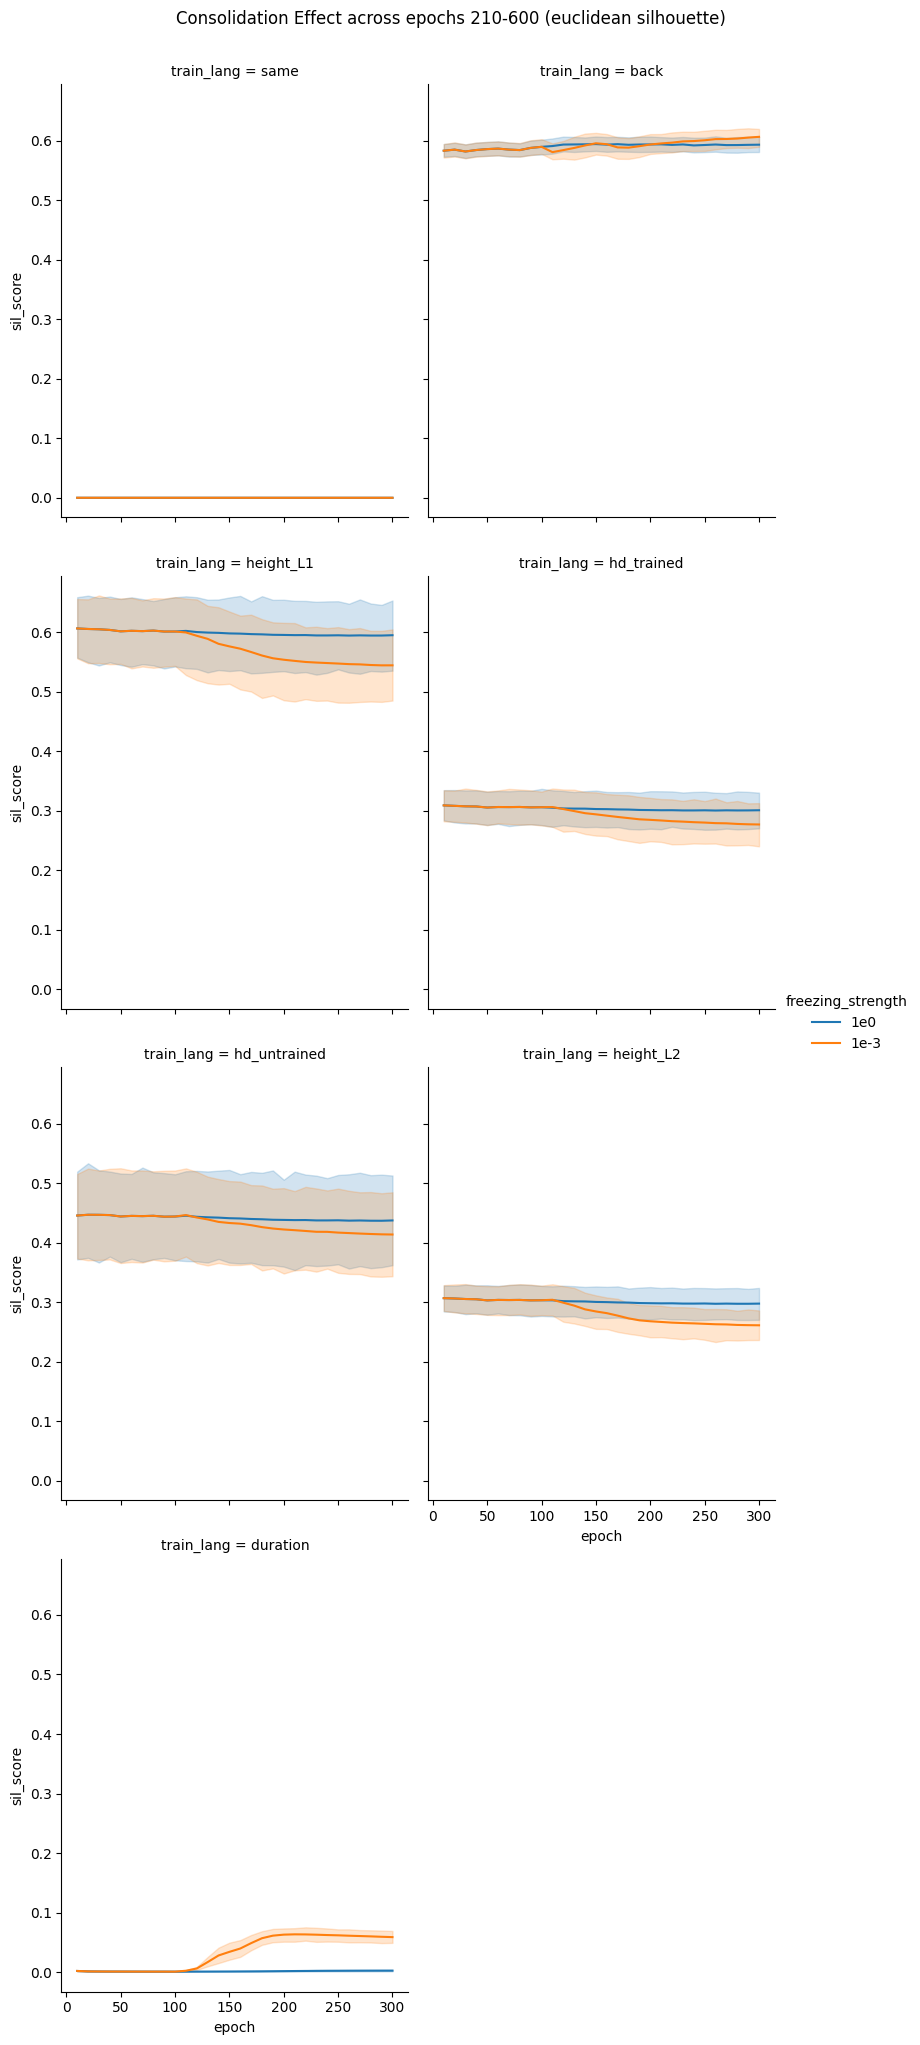

In [23]:
df = integrated_df.copy()
df["combined_inv_lr"] = df["L2_inventory_condition"] + "_" + df["learning_rate_condition"]
df = df[~df["train_lang"].isin(["N/A"])]
# df = df[df["learning_rate_condition"] == "fast"]
df = df[df["epoch"].isin(range(0, 301, 10))]
df["c"] = df["L2_inventory_condition"] + "_" + df["learning_rate_condition"] + "_" + df["train_lang"]

g = sns.relplot(
    data=df,
    x="epoch",
    y="sil_score",
    hue="freezing_strength",
    col="train_lang",
    col_wrap=2,
    kind="line",
    errorbar=("ci", 95),
    aspect=0.8
)

g.fig.suptitle("Consolidation Effect across epochs 210-600 (euclidean silhouette)", y=1.02)
for ax in g.axes.flatten():
    ax.set_xticks(range(0, 301, 50))

# g = sns.relplot(
#     data=df,
#     x="epoch",
#     y="sil_score_cos",
#     hue="freezing_strength",
#     col="c",
#     col_wrap=2,
#     kind="line",
#     errorbar=("ci", 95),
#     aspect=0.8
# )

# g.fig.suptitle("Consolidation Effect across epochs 210-600 (cosine silhouette)", y=1.02)
# for ax in g.axes.flatten():
#     ax.set_xticks(range(200, 601, 50))